This note presents an approximate $n$-qubit AND/Toffoli gate construction introduced in [GKZ25]. The idea is that, instead of directly computing the full AND, we randomly sample a small number of subsets of $[n]$, compute their parities, and combine those parity values through a smaller exact AND together with Clifford processing.

The idea is easiest to see in the simpler classical setting of the $n$-bit OR function. For each subset $S \subseteq [n]$, define
$$
\mathrm{XOR}_S(x)=\bigoplus_{i\in S} x_i
$$
to be the parity function. If $\mathrm{OR}_n(x)=0$, then every sampled parity is $0$. If $\mathrm{OR}_n(x)=1$, then for a uniformly random subset $S$, the parity $\mathrm{XOR}_S(x)$ equals $1$ with probability $1/2$. This leads to the following approximation scheme: If we sample independent subsets $S_1,\dots,S_k$ and compute
$$
g_{S_1,\dots,S_k}(x)=\mathrm{OR}_k\bigl(\mathrm{XOR}_{S_1}(x),\dots,\mathrm{XOR}_{S_k}(x)\bigr),
$$
then $g_{S_1,\dots,S_k}(x)$ always agrees with $\mathrm{OR}_n(x)$ when $\mathrm{OR}_n(x)=0$, and when $\mathrm{OR}_n(x)=1$ it fails only if all $k$ sampled parities are $0$, which happens with probability
$$
\Pr[g_{S_1,\dots,S_k}(x)\neq \mathrm{OR}_n(x)]\le 2^{-k}.
$$
Hence, $\mathrm{OR}_n$ can be approximated by computing a small number of random parities and then applying an exact OR on only $k$ bits. Performing this procedure in quantum superposition together with Clifford post-processing gives the approximate $n$-qubit Toffoli construction.

This note is organized as follows. First, we implement the vanilla log-depth exact construction from a balanced tree of 2-bit AND gates in `MultiAndLogDepth`, while keeping the same external interface as the bloq `MultiAnd`. Then, we move to implement the approximate construction in [GKZ25]. In the `ParityMask` bloq, we prepare the masked strings whose parities encode the sampled subsets. Then, in `ApproxToffoli` we package the full approximate construction into a single bloq.

The following example presents the external interface of the bloq `MultiAnd`.

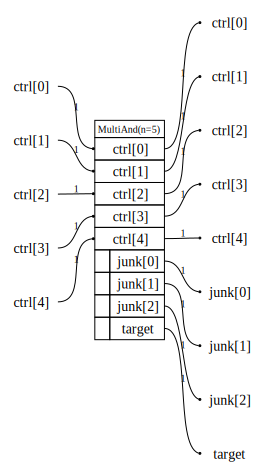

In [2]:
from qualtran.drawing import show_bloq
from qualtran.bloqs.mcmt import MultiAnd

bloq = MultiAnd(cvs=(1, 1, 1, 1, 1))
show_bloq(bloq)


Next, we give an implementation of the $n$-qubit Toffoli gate with depth $\log n$, and define it to be a bloq with the same external interface.

In [3]:
from dataclasses import dataclass
from typing import Dict, Optional, Tuple

import numpy as np

from qualtran import Bloq, BloqBuilder, Signature, Register, QBit, Side
from qualtran.bloqs.basic_gates import Toffoli, CNOT, XGate
from qualtran.drawing import (
    Circle,
    Text,
    WireSymbol,
    directional_text_box,
    show_bloq,
)


@dataclass(frozen=True)
class MultiAndLogDepth(Bloq):
    r"""A log-depth many-bit AND with the same public I/O as `MultiAnd`.

    This bloq computes the conjunction of a control register into a right-sided
    output qubit using a balanced tree of Toffoli gates. The public register
    interface matches `MultiAnd`: the input control register is preserved, the
    output is written to a right-sided `target` qubit, and the intermediate tree
    values are exposed as a right-sided `junk` register of length `n_ctrls - 2`.

    The control pattern is specified by `cvs`. An entry `cvs[i] = 1` denotes a
    positive control on `ctrl[i]`, while `cvs[i] = 0` denotes a negative control.
    Negative controls are implemented by conjugating the corresponding wire with
    `X` before and after the tree computation.

    This implementation differs from the upstream `MultiAnd` in the semantics of
    the `junk` register: here, `junk` stores balanced-tree intermediate values
    rather than the ladder-style prefix-AND values used by the reference
    implementation.

    Args:
        cvs: A tuple of control values. Each entry must be `0` or `1`. The number
            of controls is `len(cvs)`, and must be at least `3`.

    Registers:
        ctrl: An `n`-bit control register.
        junk [right]: An `n - 2` qubit junk register storing intermediate tree values.
        target [right]: The output bit.   
    """

    cvs: Tuple[int, ...]

    def __post_init__(self):
        if len(self.cvs) < 3:
            raise ValueError("MultiAndLogDepth must have at least 3 control values.")
        if any(cv not in (0, 1) for cv in self.cvs):
            raise ValueError("Each control value in `cvs` must be 0 or 1.")

    @property
    def n_ctrls(self) -> int:
        return len(self.cvs)

    @property
    def concrete_cvs(self) -> Tuple[int, ...]:
        return self.cvs

    @property
    def signature(self) -> Signature:
        return Signature(
            [
                Register("ctrl", QBit(), shape=(self.n_ctrls,)),
                Register("junk", QBit(), shape=(self.n_ctrls - 2,), side=Side.RIGHT),
                Register("target", QBit(), side=Side.RIGHT),
            ]
        )

    def _build_tree(
        self,
        bb: BloqBuilder,
        ctrls,
        junk,
        out,
    ):
        m = len(ctrls)

        if m == 1:
            ctrls[0], out = bb.add(CNOT(), ctrl=ctrls[0], target=out)
            return ctrls, junk, out

        if m == 2:
            (ctrls[0], ctrls[1]), out = bb.add(
                Toffoli(), ctrl=[ctrls[0], ctrls[1]], target=out
            )
            return ctrls, junk, out

        a = (m + 1) // 2
        b = m - a

        left_ctrls = list(ctrls[:a])
        right_ctrls = list(ctrls[a:])

        left_need = a - 1 if a > 1 else 0
        right_need = b - 1 if b > 1 else 0

        left_pool = list(junk[:left_need])
        right_pool = list(junk[left_need:left_need + right_need])

        if a == 1:
            left_out = left_ctrls[0]
        else:
            left_out = left_pool[0]
            left_ctrls, left_internal, left_out = self._build_tree(
                bb, left_ctrls, left_pool[1:], left_out
            )
            left_pool = [left_out] + left_internal

        if b == 1:
            right_out = right_ctrls[0]
        else:
            right_out = right_pool[0]
            right_ctrls, right_internal, right_out = self._build_tree(
                bb, right_ctrls, right_pool[1:], right_out
            )
            right_pool = [right_out] + right_internal

        (left_out, right_out), out = bb.add(
            Toffoli(), ctrl=[left_out, right_out], target=out
        )

        if a == 1:
            left_ctrls[0] = left_out
        else:
            left_pool[0] = left_out

        if b == 1:
            right_ctrls[0] = right_out
        else:
            right_pool[0] = right_out

        return left_ctrls + right_ctrls, left_pool + right_pool, out

    def build_composite_bloq(self, bb: BloqBuilder, **soqs):
        ctrls = list(np.ravel(soqs["ctrl"]))

        junk_reg = bb.allocate(self.n_ctrls - 2)
        junk = list(bb.split(junk_reg))

        target_reg = bb.allocate(1)
        target = bb.split(target_reg)[0]

        for i, cv in enumerate(self.concrete_cvs):
            if cv == 0:
                ctrls[i] = bb.add(XGate(), q=ctrls[i])

        ctrls, junk, target = self._build_tree(bb, ctrls, junk, target)

        for i, cv in enumerate(self.concrete_cvs):
            if cv == 0:
                ctrls[i] = bb.add(XGate(), q=ctrls[i])

        return {
            "ctrl": np.asarray(ctrls, dtype=object),
            "junk": np.asarray(junk, dtype=object),
            "target": target,
        }

    def _classical_tree(self, vals):
        m = len(vals)

        if m == 1:
            return [], np.uint8(vals[0])

        if m == 2:
            return [], np.uint8(vals[0] & vals[1])

        a = (m + 1) // 2
        b = m - a

        left_junk, left_out = self._classical_tree(vals[:a])
        right_junk, right_out = self._classical_tree(vals[a:])

        out = np.uint8(left_out & right_out)
        junk = [left_out] + left_junk + [right_out] + right_junk
        return junk, out

    def on_classical_vals(self, ctrl: np.ndarray) -> Dict[str, np.ndarray]:
        ctrl = np.asarray(ctrl, dtype=np.uint8)
        effective_ctrl = np.equal(ctrl, np.asarray(self.concrete_cvs)).astype(np.uint8)
        junk, target = self._classical_tree(list(effective_ctrl))
        return {
            "ctrl": ctrl,
            "junk": np.asarray(junk, dtype=np.uint8),
            "target": np.uint8(target),
        }

    def __pow__(self, power: int):
        if power == 1:
            return self
        if power == -1:
            return self.adjoint()
        return NotImplemented

    def wire_symbol(
        self, reg: Optional[Register], idx: Tuple[int, ...] = tuple()
    ) -> WireSymbol:
        if reg is None:
            return Text("")
        if reg.name == "ctrl":
            return Circle(filled=self.concrete_cvs[idx[0]] == 1)
        if reg.name == "target":
            return directional_text_box("∧", side=reg.side)
        if len(idx) > 0:
            pretty_text = f'{reg.name}[{", ".join(str(i) for i in idx)}]'
        else:
            pretty_text = reg.name
        return directional_text_box(text=pretty_text, side=reg.side)

    def __str__(self):
        return f"MultiAndLogDepth(n={self.n_ctrls})"

    def build_call_graph(self, ssa=None):
        cost = {Toffoli(): self.n_ctrls - 1}
        n_neg = sum(int(cv == 0) for cv in self.concrete_cvs)
        if n_neg:
            cost[XGate()] = 2 * n_neg
        return cost

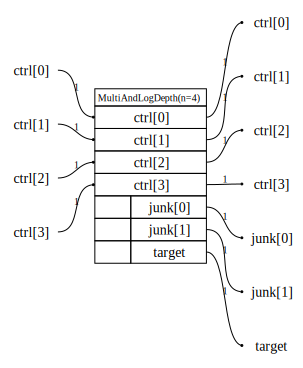

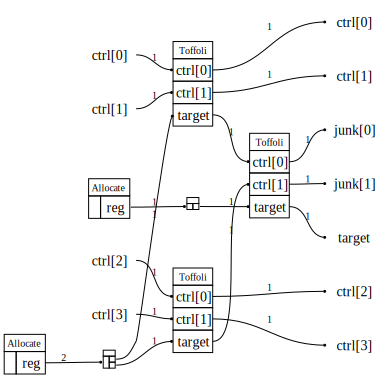

In [5]:
# Example
bloq = MultiAndLogDepth(cvs=(1, 1, 1, 1))
show_bloq(bloq)
show_bloq(bloq.decompose_bloq())

The recent work [GKZ25] gives an $\epsilon$-approximate implementation of the $n$-qubit Toffoli gate using exponentially fewer $T$ gates. The construction is based on the following classical randomized algorithm that computes the OR function: Samples $k=O(\log n)$ subsets of $[n-1]$, computes their parity values, and then applies a $k$-bit OR function together with additional Clifford operations. Implementing the above procedure in superpositions with proper negations yields an approximate implementation of the $n$-bit AND gate.

Here, we assume the sampling procedure is done, and the $k$ subsets are given as $k$ classical $(n-1)$-bit strings $s_1,\ldots,s_k$, where $[s_i]_j=1$ if and only if $j$ belows to the $i$-th subset. We first prepare the following intermediate bloq that computes $k$ $(n-1)$-bit strings $x_1,\ldots,x_k$, where $[x_i]_j=x_j\cdot [s_i]_j$ for any $i,j$. The parity of each string $x_i$ equals the parity function of the $i$-th subset, which will be computed later.

In [5]:
from dataclasses import dataclass
from typing import Tuple, Dict, Any as AnyType

from qualtran import Bloq, BloqBuilder, Signature, Register, QAny, Side
from qualtran.bloqs.basic_gates import CNOT, ZeroState
from qualtran.drawing import show_bloq


@dataclass(frozen=True)
class ParityMask(Bloq):
    """Prepare masked copies of an input register for sampled subset-parity computation.

    This bloq takes an $(n - 1)$-qubit input register `x` and prepares `k` output
    registers `x_0, ..., x_{k-1}` according to a collection of classical sample
    strings `s[0], ..., s[k-1]`. For each `i` and `j`,
    the output bit $[x_i]_j = x_j \cdot s[i]_j$.

    Equivalently, `x_i` is obtained by copying into the `i`-th output register
    exactly those positions of `x` selected by the `i`-th mask, leaving all other
    positions unchanged. The parity of each output string `x_i` therefore equals
    the parity of the subset of input bits selected by `s[i]`.

    This bloq is intended as a sample-preparation subroutine in an approximate
    multi-controlled AND / Toffoli construction based on classically sampled
    subsets. The sampling itself is assumed to have already been performed, and
    the sampled subsets are provided explicitly through `sample_strings`.

    Args:
        n: The total number of qubits in the target approximate Toffoli construction.
            This bloq acts on registers of length `n - 1`.
        k: The number of sampled subsets, equivalently the number of output registers.
        sample_strings: A tuple of `k` classical bit strings `s_1, ..., s_k`, each of length `n - 1`.
            The entry `s[i]_j` equals `1` iff the `j`-th input bit is
            included in the `i`-th sampled subset.

    Registers:
        x: An `(n - 1)`-qubit input register.
        x_0 [right]: An `(n - 1)`-qubit output register containing the masked copy
            for the first sampled subset.
        x_1 [right]: An `(n - 1)`-qubit output register containing the masked copy
            for the second sampled subset.
        ...
        x_{k-1} [right]: An `(n - 1)`-qubit output register containing the masked
            copy for the last sampled subset.
    """

    n: int
    k: int
    sample_strings: Tuple[Tuple[int, ...], ...]

    @property
    def signature(self) -> Signature:
        regs = [Register("x", QAny(self.n - 1))]
        regs += [
            Register(f"x_{i}", QAny(self.n - 1), side=Side.RIGHT)
            for i in range(self.k)
        ]
        return Signature(regs)

    def build_composite_bloq(self, bb: BloqBuilder, **soqs) -> Dict[str, AnyType]:
        if len(self.sample_strings) != self.k:
            raise ValueError("sample_strings must have length k.")
        for row in self.sample_strings:
            if len(row) != self.n - 1:
                raise ValueError("Each mask in sample_strings must have length n-1.")

        x = soqs["x"]
        x_bits = list(bb.split(x))

        out_regs = []
        for i in range(self.k):
            # Explicitly prepare |0...0> for the right-output register x_i.
            xi_bits = [bb.add(ZeroState()) for _ in range(self.n - 1)]

            for j in range(self.n - 1):
                if self.sample_strings[i][j]:
                    x_bits[j], xi_bits[j] = bb.add(
                        CNOT(), ctrl=x_bits[j], target=xi_bits[j]
                    )

            out_regs.append(bb.join(xi_bits))

        x = bb.join(x_bits)

        return {
            "x": x,
            **{f"x_{i}": out_regs[i] for i in range(self.k)},
        }

    def build_call_graph(self, ssa=None):
        cnot_count = sum(sum(int(bit) for bit in row) for row in self.sample_strings)
        return {
            ZeroState(): self.k * (self.n - 1),
            CNOT(): cnot_count,
        }

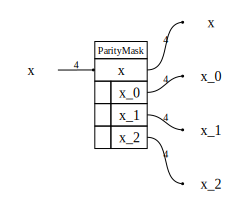

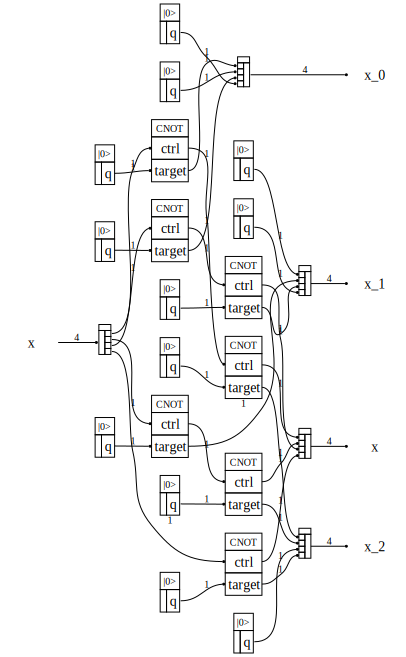

In [6]:
# Example for this ParityMask subroutine with n=5, k=3
sample_strings = (
    (1, 0, 1, 0),
    (0, 1, 1, 0),
    (1, 1, 0, 1),
)

B = ParityMask(n=5, k=3, sample_strings=sample_strings)
show_bloq(B)
show_bloq(B.decompose_bloq())

Using the bloq ParityMask as a subroutine, we obtain the circuit that approximates the $n$-qubit Toffoli gate.

In [7]:
from dataclasses import dataclass
from typing import Tuple, Dict, Any as AnyType

import numpy as np

from qualtran import Bloq, BloqBuilder, Signature, Register, QBit, QAny, Side
from qualtran.bloqs.basic_gates import XGate, CNOT, Toffoli, ZeroState
from qualtran.drawing import show_bloq


@dataclass(frozen=True)
class ApproxToffoli(Bloq):

    """Approximate multi-controlled Toffoli via sampled subset parities.

    This bloq implements an approximate `n`-qubit Toffoli / AND construction based on
    classically sampled subsets. Given an `(n - 1)`-qubit control register `ctrl`, it
    first prepares `k` masked copies determined by the sampled subset indicators in
    `sample_strings`, computes the parity of each masked copy, negates those parity
    bits, and then computes their conjunction into the output qubit `target`.

    The resulting output approximates the `(n - 1)`-bit AND of the control register.
    Equivalently, it approximates an `n`-qubit Toffoli with `(n - 1)` controls and one
    target, except that this bloq exposes a fresh right-sided output qubit `target`
    rather than toggling an input target in place.

    All intermediate data are exposed through the right-sided `junk` register. In the
    current implementation, `junk` is packed in the order
    `x_0, ..., x_{k-1}, OR_values, ancilla`, where `x_i` are the masked copies,
    `OR_values` are the computed parity bits, and `ancilla` are the auxiliary qubits
    used by the multi-control AND subroutine.

    Args:
        n: The total number of qubits in the target Toffoli interpretation. The bloq
            acts on an `(n - 1)`-qubit control register.
        k: The number of sampled subsets used in the approximation.
        sample_strings: A tuple of `k` classical bit strings, each of length `n - 1`.
            The entry `sample_strings[i][j]` equals `1` iff the `j`-th control bit is
            included in the `i`-th sampled subset.

    Registers:
        ctrl: An `(n - 1)`-qubit control register.
        junk [right]: A right-sided junk register containing all intermediate masked
            copies, parity values, and ancilla qubits.
        target [right]: The output bit of the approximate multi-controlled AND.
    """
    
    n: int
    k: int
    sample_strings: Tuple[Tuple[int, ...], ...]

    @property
    def n_junk(self) -> int:
        return self.k * (self.n - 1) + self.k + max(self.k - 2, 0)

    @property
    def signature(self) -> Signature:
        return Signature(
            [
                Register("ctrl", QBit(), shape=(self.n - 1,)),
                Register("junk", QBit(), shape=(self.n_junk,), side=Side.RIGHT),
                Register("target", QBit(), side=Side.RIGHT),
            ]
        )

    def build_composite_bloq(self, bb: BloqBuilder, **soqs) -> Dict[str, AnyType]:
        n, k = self.n, self.k

        ctrl = list(np.ravel(soqs["ctrl"]))
        x = bb.join(ctrl)

        # 1) Flip x
        x_bits = list(bb.split(x))
        for j in range(n - 1):
            x_bits[j] = bb.add(XGate(), q=x_bits[j])
        x = bb.join(x_bits)

        # 2) Parity Mask: produces right-output registers x_0, ..., x_{k-1}
        sp = ParityMask(n=n, k=k, sample_strings=self.sample_strings)
        sp_out = bb.add(sp, x=x)
        x = sp_out[0]
        x_regs = list(sp_out[1:])

        # 3) Explicitly prepare OR_values in |0...0>
        OR_regs = [bb.add(ZeroState()) for _ in range(k)]

        # 4) Parity compute
        for i in range(k):
            xi = x_regs[i]
            oi = OR_regs[i]

            xi_bits = list(bb.split(xi))
            for j in range(n - 1):
                xi_bits[j], oi = bb.add(CNOT(), ctrl=xi_bits[j], target=oi)

            x_regs[i] = bb.join(xi_bits)
            OR_regs[i] = oi

        # 5) Compute AND of negated parity bits into target
        for i in range(k):
            OR_regs[i] = bb.add(XGate(), q=OR_regs[i])

        ancilla_bits = []
        if k == 1:
            target = bb.add(ZeroState())
            OR_regs[0], target = bb.add(CNOT(), ctrl=OR_regs[0], target=target)
        elif k == 2:
            target = bb.add(ZeroState())
            (OR_regs[0], OR_regs[1]), target = bb.add(
                Toffoli(), ctrl=[OR_regs[0], OR_regs[1]], target=target
            )
        else:
            and_k = MultiAndLogDepth(cvs=(1,) * k)
            OR_ctrl = np.asarray(OR_regs, dtype=object)
            OR_ctrl, ancilla, target = bb.add(and_k, ctrl=OR_ctrl)
            OR_regs = list(np.ravel(OR_ctrl))
            ancilla_bits = list(np.ravel(ancilla))

        for i in range(k):
            OR_regs[i] = bb.add(XGate(), q=OR_regs[i])

        # 6) Uncompute parity so OR_values return to |0...0>
        for i in reversed(range(k)):
            xi = x_regs[i]
            oi = OR_regs[i]

            xi_bits = list(bb.split(xi))
            for j in range(n - 1):
                xi_bits[j], oi = bb.add(CNOT(), ctrl=xi_bits[j], target=oi)

            x_regs[i] = bb.join(xi_bits)
            OR_regs[i] = oi

        # 7) Unflip x
        x_bits = list(bb.split(x))
        for j in range(n - 1):
            x_bits[j] = bb.add(XGate(), q=x_bits[j])
        x = bb.join(x_bits)

        ctrl = np.asarray(bb.split(x), dtype=object)

        # Pack junk as: x_0, ..., x_{k-1}, OR_values, ancilla
        junk_bits = []
        for i in range(k):
            junk_bits.extend(list(bb.split(x_regs[i])))
        junk_bits.extend(OR_regs)
        junk_bits.extend(ancilla_bits)

        return {
            "ctrl": ctrl,
            "junk": np.asarray(junk_bits, dtype=object),
            "target": target,
        }

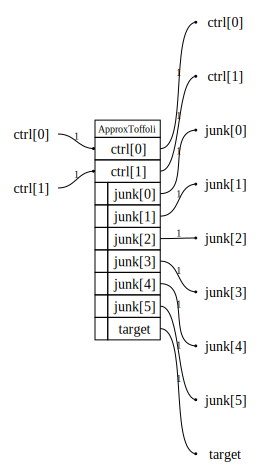

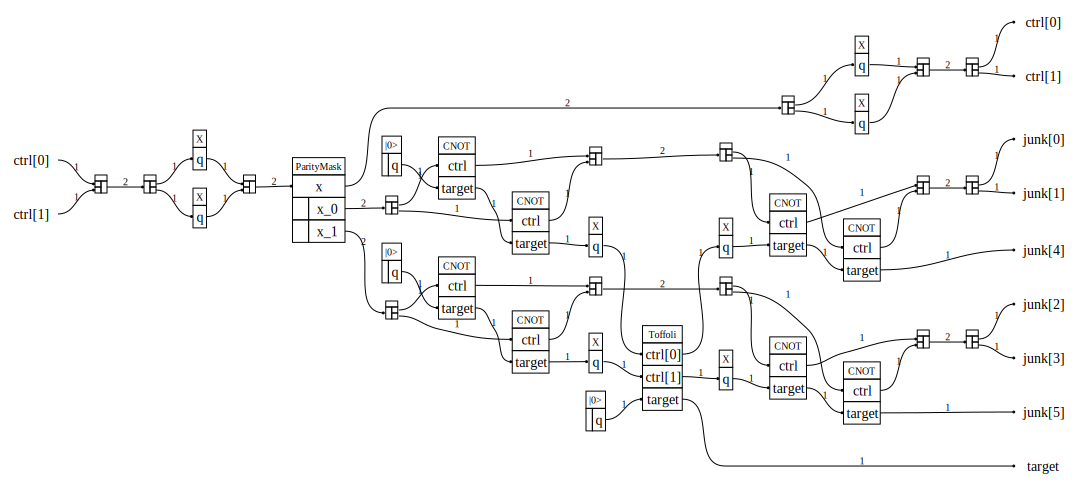

In [8]:
# Example: n = 3, k = 2
n = 3
k = 2
sample_strings = (
    (1, 0),
    (0, 1),
)

B = ApproxToffoli(n=n, k=k, sample_strings=sample_strings)
show_bloq(B)
show_bloq(B.decompose_bloq())

Finally, we test the correctness of the algorithm on classical inputs/outputs. In the example below, we set $n=17$ and $k=4$. We randomly sample $x$ and sample_strings every time. The expected error probability is $2^{-k}=1/16$.

In [35]:
import random

# n = 17 (16 controls), k = 4
n = 17
k = 4
m = n - 1
ALL_ONES = (1 << m) - 1

def random_sample_string(width: int) -> tuple[int, ...]:
    return tuple(random.randint(0, 1) for _ in range(width))

def int_to_bits(x: int, width: int) -> tuple[int, ...]:
    return tuple((x >> j) & 1 for j in range(width))

def ideal_toffoli_t(x_int: int, t_in: int) -> int:
    # New ApproxToffoli outputs a fresh target bit
    return int(x_int == ALL_ONES)

# ----------------------------
# Single randomized example
# ----------------------------

# Randomly sample x
x_int = random.randint(0, ALL_ONES)
t_in = 0

# Fresh random sample strings
sample_strings = tuple(random_sample_string(m) for _ in range(k))

B = ApproxToffoli(n=n, k=k, sample_strings=sample_strings)

out = B.call_classically(
    ctrl=int_to_bits(x_int, m),
)

t_out = out[2]
t_expected = ideal_toffoli_t(x_int, t_in)

print("Single randomized test case")
print(f"  x (binary) = {x_int:016b}")
print(f"  sample_strings   = {sample_strings}")
print(f"  Approx t  = {t_out}")
print(f"  Ideal t   = {t_expected}")
print(f"  MATCH     = {t_out == t_expected}")

Single randomized test case
  x (binary) = 1100111100000011
  sample_strings   = ((0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0), (0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1), (1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1), (1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0))
  Approx t  = 0
  Ideal t   = 0
  MATCH     = True
